In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import expm, schur
from scipy.optimize import newton
from scipy.special import erf

np.set_printoptions(precision=4)

In [2]:
def format_plot(
    ax,
    xlabel=r"$ t \hspace{0.5} [s]$",
    ylabel=r"$ v \hspace{0.5} [\frac{m}{s}$]   / $ a \hspace{0.5} [\frac{m}{s^2}]$",
    title="State vector evolution",
    label=["v [m/s]", "a[m/²]"],
    xtitle=0.0,
    loc=(0.7, 0.8),
) -> None:
    # seting formating standards
    # ticks
    tickparams = dict(  # settings for plot axis
        size=3,
        labelsize=12,
        labelcolor=(0.0, 0.0, 0.0, 0.6),  # last element control the brightness
        color=(0.0, 0.0, 0.0, 0.6),  # tick-colors
    )

    # Labels
    labelfonts = dict(  # settings for plot labels
        fontsize=14,
        labelpad=15,
        alpha=0.6,
    )

    # titles
    titlefonts = dict(  # settings for plot titles
        size=16,
        pad=35,  # shif the position with respect to the default
        ma="left",  # text aligment
        x=xtitle,
        alpha=0.6,
    )

    # apply standards
    ax.tick_params(**tickparams)  # type: ignore

    ax.set_xlabel(xlabel, **labelfonts)  # type: ignore
    ax.set_ylabel(ylabel, **labelfonts)  # type: ignore

    ax.set_title(title, **titlefonts)  # type: ignore

    # displacing main axes
    ax.spines["left"].set_position(("outward", 20))  # type: ignore
    ax.spines["bottom"].set_position(("outward", 20))  # type: ignore

    # hiding complemetary axes
    ax.spines["top"].set_visible(False)  # type: ignore
    ax.spines["right"].set_visible(False)  # type: ignore

    ax.legend(label, loc=loc, fontsize=14, labelcolor=(0.0, 0.0, 0.0, 0.6))  # type: ignore

# Design of a Speed Control System (Cruise Control)

Imagine the following (highly simplified) dynamics of a car:

$$ \frac{dv}{dt} = a - \frac{μv^2}{m}$$

Where $v$ is the velocity and $a$ is an input acceleration. Think of $a$ as operating the gas pedal to reach a target speed ($v_t$).

Your task is to design an automatic controller for $a$ so that the system converges to $v_t$. In other words:

$$\frac{dv}{dt} \Big |_{v_t}= 0$$



## Task

Find a suitable expression for:

$$\frac{d a}{dt}$$

Don't forget that $a$ must react to the difference $$(v - v_t)$$

If you don't know where to start, you can try a simple proportional feedback:

$$\frac{d a}{dt} = -σ(v - v_t)$$

(It won't quite work, but it is a good exercise to get you going).

Make sure you understand what the control is supposed to achieve.

## Task

Find the fixed point $\begin{bmatrix}v_* \\ a_* \end{bmatrix}$ of your dynamics. That is:

$$\frac {d}{dt} \begin{bmatrix} v_* \\ a_* \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$


## Task

Find a linear approximation for your dynamics. It will have the following form:

$$ \frac {d}{dt} \begin{bmatrix} Δv  \\ Δa \end{bmatrix} = 
                \begin{bmatrix} \frac{d \dot{v} }{dv} \Big|_{*} & \frac{d\dot{v} }{da} \Big|_{*} \\
                                \frac{d \dot{a} }{dv} \Big|_{*} & \frac{d\dot{a} }{da} \Big|_{*} \end{bmatrix} \begin{bmatrix} Δv  \\ Δa \end{bmatrix} $$
                                
or:

$$\dot Δz = JΔz$$
                                

## Task

Find the general solution for $Δz(t)$ using eigenvalues and eigenvectors.

Implement your solution in Python/Numpy using the functions `np.linalg.eig()` and `np.linalg.solve()`.

Consider the following parameters for your calculation:

> - Mass of the car (m) : 1000 [kg] <br>
> - $v_t$ = 100 [km/h] <br>
> - µ = 0.5 [kg/m] <br>
(this already includes the drag coefficient, the cross-sectional area of the car, and the air density)


and the following initial conditions:

> - $Δv_0$ = -10 [m/s]
> - $Δa_0$ = 0 [m/$s^2$]


You can start by choosing the value of σ for the phase portrait where the system becomes a stable star, and from there you can play with σ and see if you find an acceptable solution.

Make sure you plot v and a for a sufficiently large time span so you can observe how the dynamics evolve.

In [3]:
μ  = 0.5 #kg/m
Vt = 100 #km/h
m  = 1000 #kg
σ  = 10
J  = np.array([[-2*(µ/m)*Vt , 1],
               [σ , 0]])
Λ, Q = np.linalg.eig(J)
J,Λ, Q

(array([[-0.1,  1. ],
        [10. ,  0. ]]),
 array([-3.2127,  3.1127]),
 array([[-0.3059, -0.2972],
        [ 0.9521, -0.9548]]))

In [4]:
μ  = 0.5 #kg/m
Vt = 100*1000/3600 #m/s
m  = 1000 #kg
σ  =0.000771604938271605/4
J  = np.array([[-2*(µ/m)*Vt , 1],
               [-σ , 0]])
Λ, Q = np.linalg.eig(J)
J, Λ, Q
#print(((-2*µ/m*Vt)**2))

(array([[-2.7778e-02,  1.0000e+00],
        [-1.9290e-04,  0.0000e+00]]),
 array([-0.0139, -0.0139]),
 array([[ 0.9999, -0.9999],
        [ 0.0139, -0.0139]]))

[[4.4589e+08]
 [4.4589e+08]]


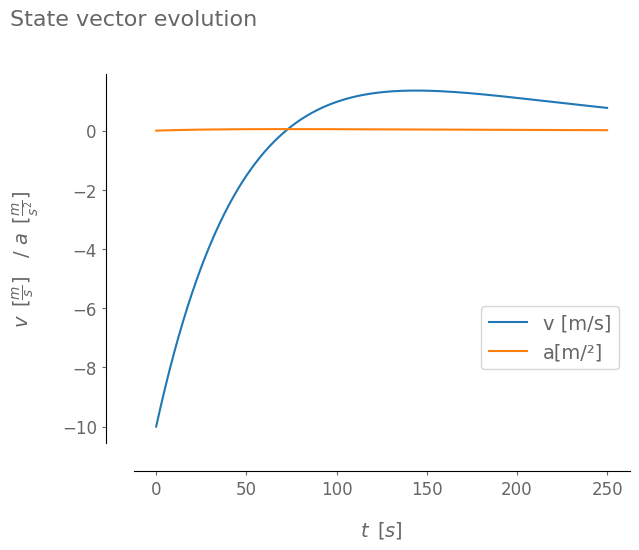

In [5]:
fig, ax = plt.subplots()

Λ, Q = np.linalg.eig(J)
x0 = np.array([-10.0, 0.]).reshape(2, 1)

n = 500
t = np.linspace(0, 250, n).reshape(n, 1)

C = np.linalg.solve(Q,x0)
sol = np.array(Q@(C*np.exp(Λ.reshape(-1,1)@t.reshape(1,-1))))
print(C)


ax.plot(t, sol.T)#.reshape(n, 2))
format_plot(ax, loc=(0.7, 0.2))

After that, you can also try the following initial conditions:

> - $Δv_0$ = -10 [m/s]
> - $Δa_0$ = -1 [m/$s^2$]

How do the results look now?

## Task

Ok ... at this point it should be clear that you need a better controller.

Try the following dynamics:

$$ \frac{dv}{dt} = a - \frac{μv^2}{m}$$
$$\frac{da}{dt} = -σ(v -v_t) - γ(a - \frac{μv_t^2}{m})$$

With $\gamma$ you get feedback control on $a$ itself (now the system is fully actuated).

Find a linearized version of these dynamics by applying the same steps as in the previous task.


## Task

Find the general solution for $Δz(t)$ again using eigenvalues and eigenvectors and implement it in Python.

Tips:
> * Create a function that returns the Jacobian matrix based on the required parameters (i.e. $\gamma, \mu, m, \sigma$ and $v_t$).
> * We discussed how to set both control gains $\gamma$ and $\sigma$. In case you need some help, you can start from the expression for the eigenvalues of $J$:
>
>     $$\lambda = \frac{\tau}{2} \pm \frac{1}{2} \sqrt{\tau^2 - 4 \Delta}$$
>
> * Make sure that your system is critically damped (or close to it).

and the following initial conditions:

- $Δv_0$ = -10 [m/s]
- $Δa_0$ = 0 [m/$s^2$]


In [6]:
def jacobi(γ, μ, m, σ, Vt):
    J = np.array([[-2*µ/m *Vt , 1],[-σ , -γ]])
    return J


μ  = 0.5 #kg/m
Vt = 100*1000/3600 #m/s
m  = 1000 #kg

t_c  = 1000 #s
γ = 10 #-2*µ/m*Vt - 2*np.log(0.01)/t_c
#σ = ((-2*µ/m*Vt)**2)/4
σ = ((γ -2*µ/m*Vt)**2)/4


J = jacobi(γ, μ, m, σ, Vt)
Λ, Q = np.linalg.eig(J)
J ,Λ, Q, σ

(array([[ -0.0278,   1.    ],
        [-24.8613, -10.    ]]),
 array([-5.0139, -5.0139]),
 array([[-0.1966, -0.1966],
        [ 0.9805,  0.9805]]),
 24.861304012345673)

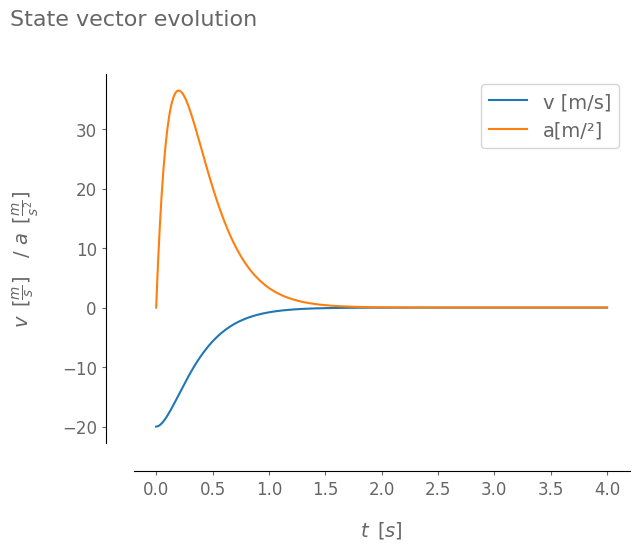

In [7]:
J = jacobi(γ, μ, m, σ, Vt)
Λ, Q = np.linalg.eig(J)
x1 = np.array([-20, 0.0]).reshape(2, 1)
n = 500
t = np.linspace(0, 4, n).reshape(n, 1)
C = np.linalg.solve(Q,x1)

sol = np.array(Q@(C*np.exp(Λ.reshape(-1,1)@t.reshape(1,-1))))

fig, ax = plt.subplots()

#ax.plot(t, sol.reshape(n, 2))
ax.plot(t, sol[0])
ax.plot(t, sol[1])
format_plot(ax)

## Extra Task

Use the standard ODE integrator (`scipy.integrate.solve_ivp()`) to compute the time evolution of both the full and the linearized models. This method will remain as a black-box now, but you will meet it again soon in other courses.

As you can read in the documentation, `scipy.integrate.solve_ivp()` requires the input function to have `t` as the first variable (even if the function does not use `t`).

Both the linearized and the full dynamics must return the time derivatives of $v$ and $a$ (i.e., the derivative of the state vector).

In [8]:
def dyn(t, x, γ, μ, m, σ, Vt):
    v_dot = x[1] - μ * x[0] ** 2 / m
    w_dot = -σ * (x[0] - Vt) - γ * (x[1] - μ * Vt**2 / m)
    return v_dot, w_dot


def dyn_l(t, x, γ, μ, m, σ, Vt):
    # fmt: off
    J = np.array([[-2.0 * Vt * μ / m,  1.0], 
                  [      -σ,           -γ ]])
    # fmt: on
    return J @ x

The following simulations overlay both dynamics (don't forget to add the fixed point to the linearized dynamics). Can you explain why the linearized dynamics reproduce the full dynamics so well in this case?

Hint: Please consult the scipy documentation on how to use `scipy.integrate.solve_ivp()`.

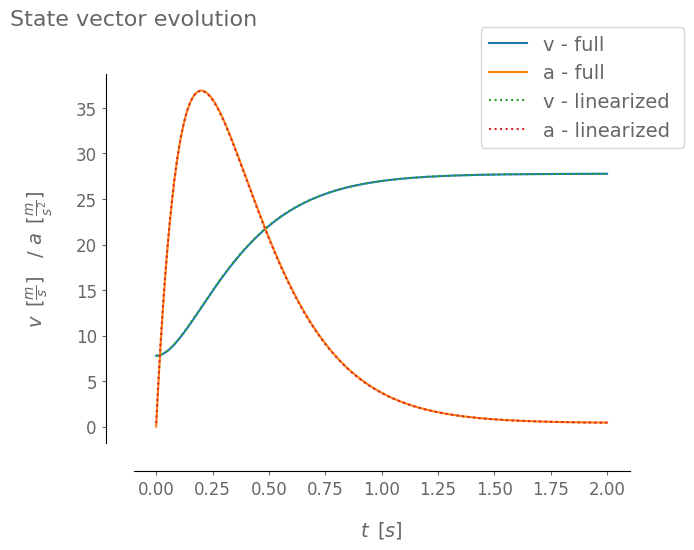

In [9]:
plt.close("all")
fig, ax = plt.subplots()
tf = 2
μ = 0.5
Vt = 100.0 / 3.6
m = 1000.0
σ = 5.3
args = μ, m, σ, Vt

# γ = newton(find_γ,100,args=args)

γ = 10.0
σ = 0.25 * (γ - 2 * μ / m * Vt) ** 2

args = γ, μ, m, σ, Vt
x0 = np.array([Vt - 20.0, 0.0])  # Initial values - complete dynamic


sol = solve_ivp(dyn, [0, tf], x0, args=args, t_eval=np.linspace(0, tf, 200))
ax.plot(sol.t, sol.y.T)


x0_l = np.array([-20.0, 0.0])  # Initial values - linearized dynamic
sol = solve_ivp(dyn_l, [0, tf], x0_l, args=args, t_eval=np.linspace(0, tf, 200))

fix = np.array([Vt, μ * Vt**2 / m]).reshape(1, 2)
ax.plot(sol.t, sol.y.T + fix, ls=":")


label = ["v - full", "a - full", "v - linearized ", "a - linearized "]

format_plot(ax, label=label)

Finally ... you can overlay the numerical non-linear model with you linearized model solved via DMD. The result should also give you a parfect match. 

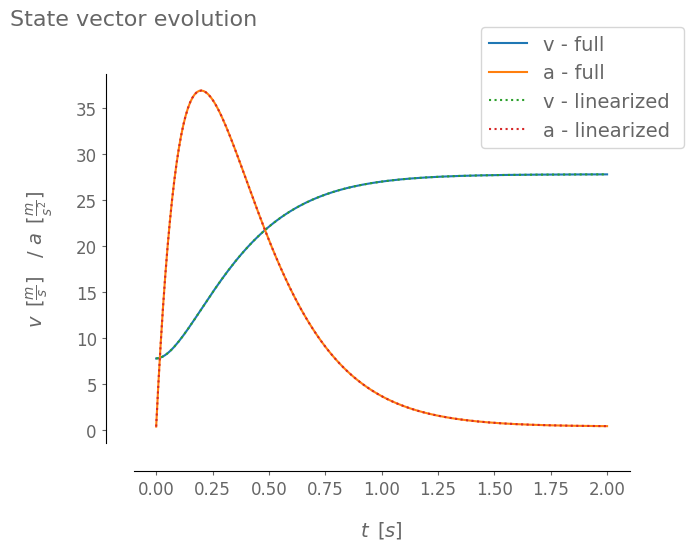

In [10]:
plt.close("all")
fig, ax = plt.subplots()

J = jacobi(γ, μ, m, σ, Vt)#
Λ, Q = np.linalg.eig(J)#
x1 = np.array([-20, 0.0]).reshape(2, 1)
n = 200
t = np.linspace(0, tf, n)#.reshape(n, 1)
c = np.linalg.solve(Q, x1) #

sol = 0
for i in range(c.size):
    sol = (sol + c[i]*Q[:,i].reshape(c.size, 1)*np.exp(Λ[i]*t))

ax.plot(t, sol.T+fix)


x0_l = np.array([-20.0, 0.0])  # Initial values - linearized dynamic
sol = solve_ivp(dyn_l, [0, tf], x0_l, args=args, t_eval=np.linspace(0, tf, 200))

fix = np.array([Vt, μ * Vt**2 / m]).reshape(1, 2)
ax.plot(sol.t, sol.y.T + fix, ls=":")

format_plot(ax, label=label)